Mental Wellness as a function to Screen Time and the Digital Lifestyle

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [61]:
# import the dataset to EDA
df = pd.read_csv('../data/genz_mental_wellness_synthetic_dataset.csv')
df.head()

,Age,Gender,Country,Student_Working_Status,Daily_Social_Media_Hours,Screen_Time_Hours,Night_Scrolling_Frequency,Online_Gaming_Hours,Content_Type_Preference,Exercise_Frequency_per_Week,...,Study_Work_Hours_per_Day,Overthinking_Score,Anxiety_Score,Mood_Stability_Score,Social_Comparison_Index,Sleep_Quality_Score,Motivation_Level,Emotional_Fatigue_Score,Wellbeing_Index,Burnout_Risk
0,24,Male,Canada,Working,4.81,6.93,2.61,2.07,News,5.41,...,11.42,4.95,4.13,5.74,4.67,6.27,6.13,6.45,4.28,Medium
1,21,Male,USA,Student,4.16,7.94,1.85,3.58,Gaming,3.41,...,6.98,5.91,3.63,5.75,5.38,7.37,6.27,3.74,5.23,Medium
2,25,Male,Pakistan,Student,3.07,7.45,2.96,2.85,Entertainment,3.40,...,7.79,4.06,5.67,6.03,2.41,6.48,4.82,6.69,3.72,High
3,22,Female,Pakistan,Student,4.41,7.34,4.51,3.37,Educational,2.19,...,6.61,6.10,4.78,4.85,5.86,7.27,5.17,5.96,3.97,High
4,24,Male,Pakistan,Student,2.97,5.76,2.36,1.77,Educational,4.93,...,4.81,5.22,4.23,5.05,5.54,6.34,5.72,2.22,4.63,Medium


In [62]:
df.columns

Index(['Age', 'Gender', 'Country', 'Student_Working_Status',
       'Daily_Social_Media_Hours', 'Screen_Time_Hours',
       'Night_Scrolling_Frequency', 'Online_Gaming_Hours',
       'Content_Type_Preference', 'Exercise_Frequency_per_Week',
       'Daily_Sleep_Hours', 'Caffeine_Intake_Cups', 'Study_Work_Hours_per_Day',
       'Overthinking_Score', 'Anxiety_Score', 'Mood_Stability_Score',
       'Social_Comparison_Index', 'Sleep_Quality_Score', 'Motivation_Level',
       'Emotional_Fatigue_Score', 'Wellbeing_Index', 'Burnout_Risk'],
      dtype='object')

In [63]:
df["Wellbeing_Index"].describe()

count    10000.000000
mean         3.870213
std          1.238940
min          1.000000
25%          3.020000
50%          3.870000
75%          4.700000
max          8.860000
Name: Wellbeing_Index, dtype: float64

In [64]:
df.dtypes.astype(str).sort_values()

Daily_Sleep_Hours              float64
Emotional_Fatigue_Score        float64
Motivation_Level               float64
Sleep_Quality_Score            float64
Daily_Social_Media_Hours       float64
Screen_Time_Hours              float64
Night_Scrolling_Frequency      float64
Online_Gaming_Hours            float64
Social_Comparison_Index        float64
Exercise_Frequency_per_Week    float64
Wellbeing_Index                float64
Caffeine_Intake_Cups           float64
Study_Work_Hours_per_Day       float64
Overthinking_Score             float64
Anxiety_Score                  float64
Mood_Stability_Score           float64
Age                              int64
Student_Working_Status          object
Country                         object
Gender                          object
Content_Type_Preference         object
Burnout_Risk                    object
dtype: object

In [65]:
X = df.drop('Wellbeing_Index', axis=1).copy()
y = df['Wellbeing_Index'].copy() #target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)


In [66]:
X.describe()

,Age,Daily_Social_Media_Hours,Screen_Time_Hours,Night_Scrolling_Frequency,Online_Gaming_Hours,Exercise_Frequency_per_Week,Daily_Sleep_Hours,Caffeine_Intake_Cups,Study_Work_Hours_per_Day,Overthinking_Score,Anxiety_Score,Mood_Stability_Score,Social_Comparison_Index,Sleep_Quality_Score,Motivation_Level,Emotional_Fatigue_Score
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,21.992900,4.005883,7.016991,2.986009,1.607241,2.994855,6.512031,1.505871,6.030983,5.001868,4.747556,5.161021,4.403556,6.514447,5.086132,5.582222
std,2.589309,1.480509,1.792529,1.197035,1.300045,1.478248,1.194194,0.934069,1.975337,1.143179,1.305593,1.257055,1.336479,1.427806,1.308351,1.416558
min,18.000000,0.500000,2.000000,0.000000,0.000000,0.000000,3.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.020000,1.000000,1.000000
25%,20.000000,3.010000,5.810000,2.187500,0.470000,1.960000,5.710000,0.800000,4.700000,4.240000,3.840000,4.310000,3.470000,5.550000,4.200000,4.620000
50%,22.000000,3.990000,7.000000,2.980000,1.460000,3.010000,6.520000,1.480000,6.030000,5.000000,4.740000,5.170000,4.400000,6.530000,5.080000,5.580000
75%,24.000000,4.982500,8.210000,3.790000,2.500000,4.000000,7.320000,2.150000,7.340000,5.760000,5.630000,6.000000,5.320000,7.490000,5.950000,6.540000
max,26.000000,10.000000,14.000000,7.000000,6.000000,7.000000,10.000000,6.000000,13.050000,9.510000,9.690000,10.000000,9.420000,10.000000,10.000000,10.000000


In [67]:
X_train.select_dtypes(include=['number']).agg([
    "mean",
    "median",
    "std",
    "min",
    "max",
    lambda x: x.quantile(0.75) - x.quantile(0.25)
])

,Age,Daily_Social_Media_Hours,Screen_Time_Hours,Night_Scrolling_Frequency,Online_Gaming_Hours,Exercise_Frequency_per_Week,Daily_Sleep_Hours,Caffeine_Intake_Cups,Study_Work_Hours_per_Day,Overthinking_Score,Anxiety_Score,Mood_Stability_Score,Social_Comparison_Index,Sleep_Quality_Score,Motivation_Level,Emotional_Fatigue_Score
mean,21.983250,3.996089,7.010696,2.979885,1.610590,2.986536,6.51371,1.514516,6.021349,4.994445,4.738779,5.171419,4.391955,6.514769,5.091708,5.572111
median,22.000000,3.980000,7.000000,2.970000,1.470000,3.010000,6.53000,1.500000,6.030000,4.990000,4.730000,5.180000,4.390000,6.530000,5.080000,5.570000
std,2.594862,1.482027,1.791599,1.193448,1.302666,1.472425,1.19771,0.934630,1.965913,1.139683,1.306241,1.255224,1.338288,1.422005,1.315346,1.423951
min,18.000000,0.500000,2.000000,0.000000,0.000000,0.000000,3.00000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.260000,1.000000,1.000000
max,26.000000,10.000000,14.000000,7.000000,6.000000,7.000000,10.00000,6.000000,13.050000,9.510000,9.690000,9.770000,9.420000,10.000000,10.000000,10.000000
<lambda>,4.000000,1.970000,2.400000,1.600000,2.032500,2.060000,1.62000,1.340000,2.622500,1.520000,1.790000,1.680000,1.850000,1.930000,1.760000,1.920000


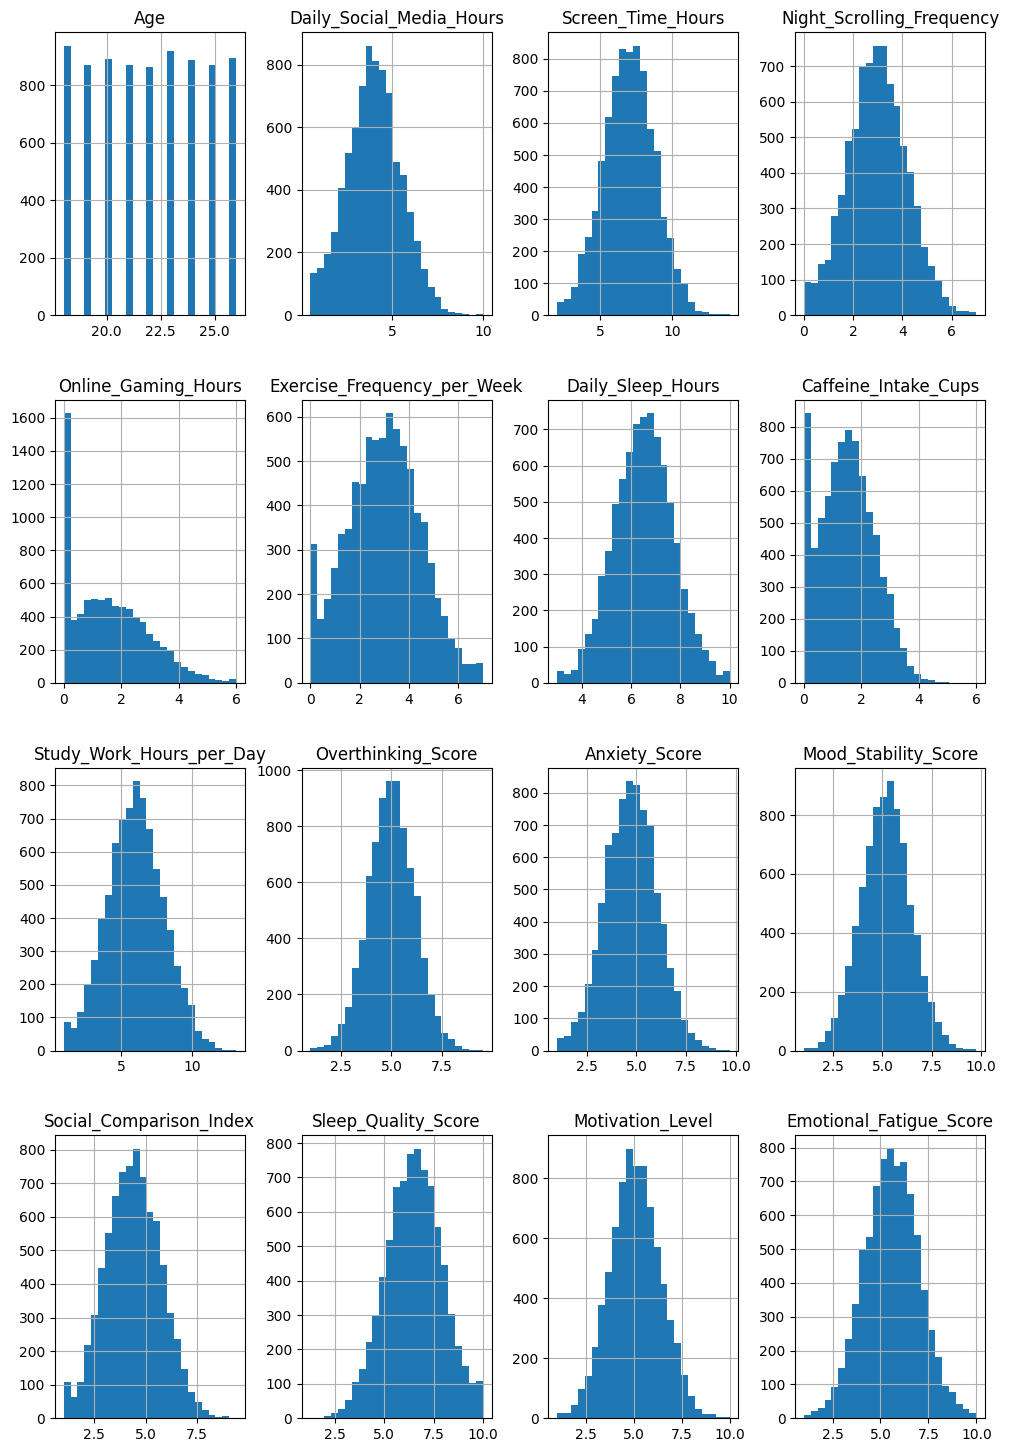

In [68]:
# Distribution of the numerical features
X_train.select_dtypes(include=['number']).hist(
    bins = 25,
    figsize = (12, 18)
)

plt.show()

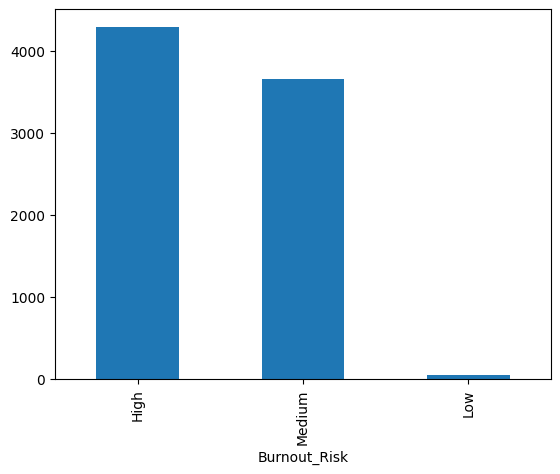

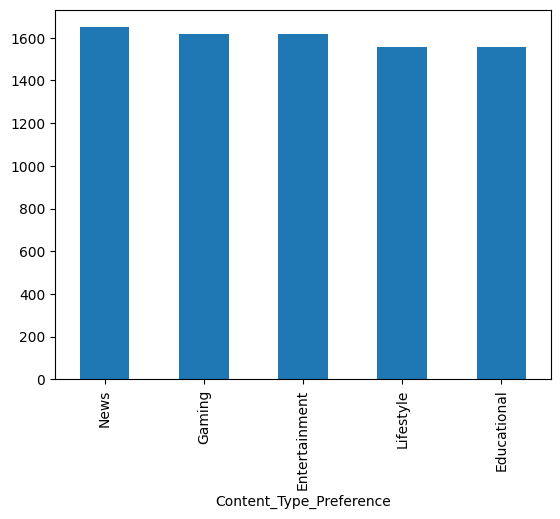

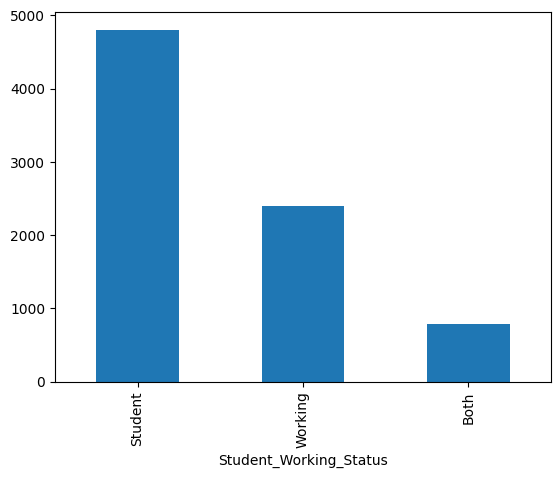

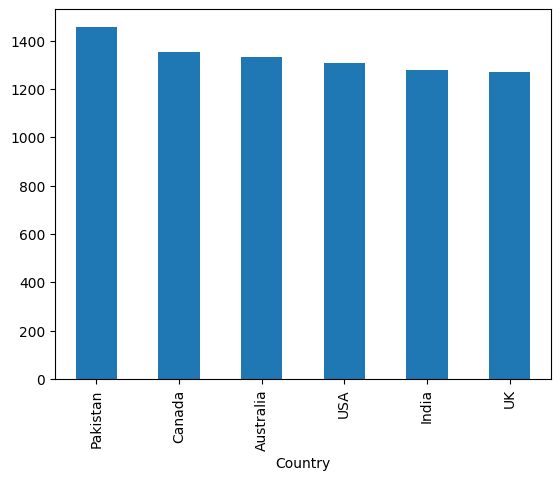

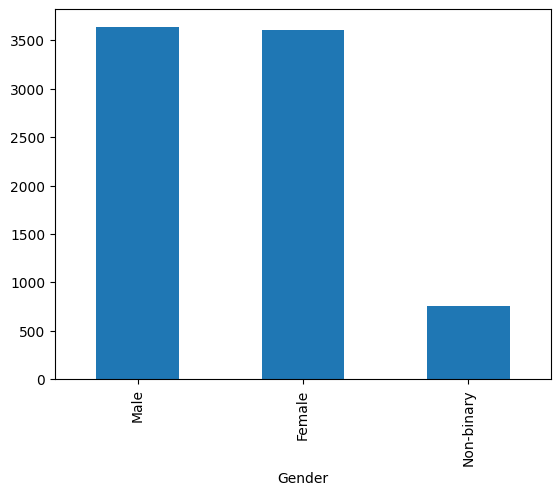

In [69]:
# Distribution of the categorical features
X_train["Burnout_Risk"].value_counts().plot.bar()
plt.show()

X_train["Content_Type_Preference"].value_counts().plot.bar()
plt.show()

X_train["Student_Working_Status"].value_counts().plot.bar()
plt.show()

X_train["Country"].value_counts().plot.bar()
plt.show()

X_train["Gender"].value_counts().plot.bar()
plt.show()

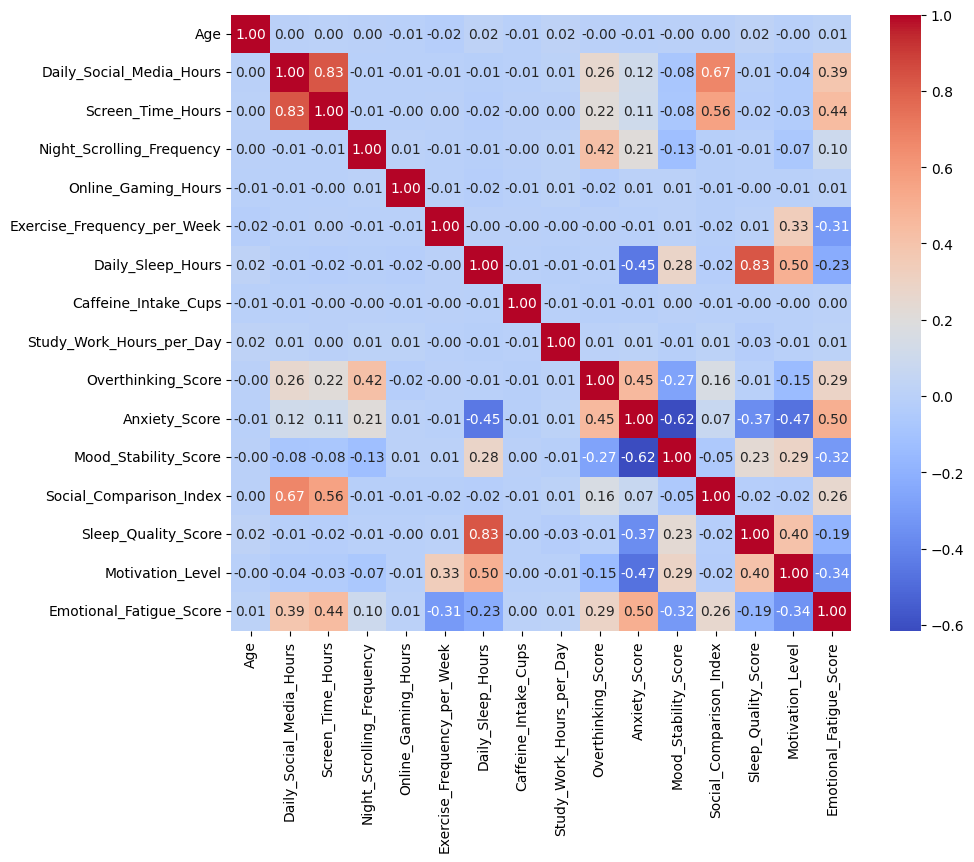

In [70]:
df_corr = X_train.select_dtypes(include=['number']).copy()

corr = df_corr.corr()

plt.figure(figsize=(10,8))

sns.heatmap(corr, 
            annot=True,
            cmap="coolwarm",
            fmt=".2f")
plt.show()

In [71]:
numeric_features = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=["number"]).columns.tolist()

print("Numéricas:", numeric_features)
print("Categóricas:", categorical_features)

Numéricas: ['Age', 'Daily_Social_Media_Hours', 'Screen_Time_Hours', 'Night_Scrolling_Frequency', 'Online_Gaming_Hours', 'Exercise_Frequency_per_Week', 'Daily_Sleep_Hours', 'Caffeine_Intake_Cups', 'Study_Work_Hours_per_Day', 'Overthinking_Score', 'Anxiety_Score', 'Mood_Stability_Score', 'Social_Comparison_Index', 'Sleep_Quality_Score', 'Motivation_Level', 'Emotional_Fatigue_Score']
Categóricas: ['Gender', 'Country', 'Student_Working_Status', 'Content_Type_Preference', 'Burnout_Risk']


In [72]:
# Colunas numericas: imputar + escalar
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [73]:
# Colunas categóricas: imputing and one-hot-encoding
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

In [74]:
preprocessor = ColumnTransformer(
    transformers=[
        ('numerical', numeric_transformer, numeric_features),
        ('categorical', categorical_transformer, categorical_features)
    ]
)

In [75]:
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', KNeighborsRegressor(n_neighbors=8))
])

In [77]:
model.fit(X_train, y_train)

# previsoes
y_pred = model.predict(X_test)

# Avaliação de regressão
mae = mean_absolute_error(y_test, y_pred)
rmse =mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nResultados no conjunto de teste:")
print(f"  MAE   = {mae:.3f}")
print(f"  RMSE  = {rmse:.3f}")
print(f"  R2    = {r2:.3f}")

comparison = pd.DataFrame({
    'Real': y_test.values,
    'Predito': y_pred
})
print("\nPrimeiras previsões vs real:")
print(comparison.head(10))


Resultados no conjunto de teste:
  MAE   = 0.255
  RMSE  = 0.105
  R2    = 0.932

Primeiras previsões vs real:
   Real  Predito
0  3.74  3.65500
1  3.82  3.88875
2  2.20  2.67250
3  6.01  5.45375
4  2.66  2.73500
5  5.21  4.52625
6  3.80  3.50125
7  2.47  2.94500
8  3.44  3.30875
9  3.19  3.35000
